1- Loading and Pre-processing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data generated by benchmark.py
df = pd.read_csv('simulation_results.csv')

# Metric: Orders per Step (Velocity)
# This helps us see the exact moment the system slows down during a failure
df['Throughput_Velocity'] = df.groupby(['Mechanism', 'iteration'])['Throughput'].diff().fillna(0)

print(f"Dataset loaded: {len(df)} rows.")
print(f"Mechanisms found: {df['Mechanism'].unique()}")

Dataset loaded: 54045 rows.
Mechanisms found: ['greedy' 'cnp' 'auction']


***Comparative Analysis***: This section directly compares the mechanisms we choosed (Greedy, CNP, Auction) to determine which is superior under specific conditions.

##### 1. Coordination Type Performance Comparison

In [2]:
# We take the LAST step of every unique run to get the total performance
final_runs = df.groupby(['Mechanism', 'Scenario', 'iteration']).last().reset_index()

print(f"Success! Data loaded. Total runs found: {len(final_runs)}")

Success! Data loaded. Total runs found: 45


C:\Users\ff\AppData\Local\Temp\ipykernel_4344\655860790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_runs, x='Mechanism', y='Throughput', palette='Set2', ax=axes[0])
C:\Users\ff\AppData\Local\Temp\ipykernel_4344\655860790.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_runs, x='Mechanism', y='Idle_Time', palette='Set2', ax=axes[1])
C:\Users\ff\AppData\Local\Temp\ipykernel_4344\655860790.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_runs, x='Mechanism', y='Fairness_Gini', palette='Set2', ax=a

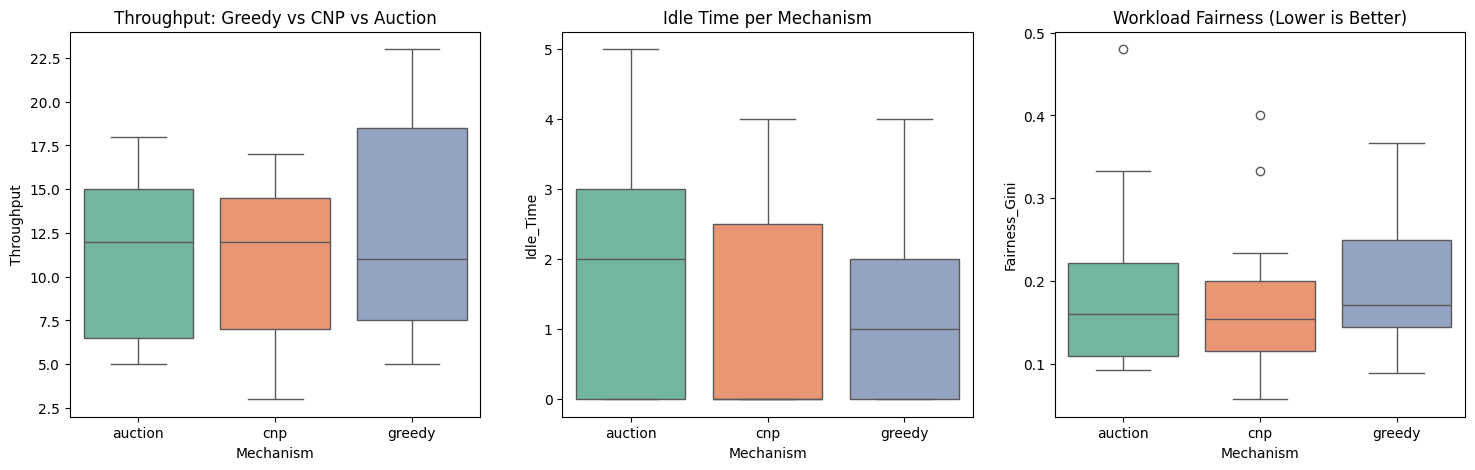

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Throughput by Mechanism
sns.boxplot(data=final_runs, x='Mechanism', y='Throughput', palette='Set2', ax=axes[0])
axes[0].set_title('Throughput: Greedy vs CNP vs Auction')

# Idle Time comparison
sns.boxplot(data=final_runs, x='Mechanism', y='Idle_Time', palette='Set2', ax=axes[1])
axes[1].set_title('Idle Time per Mechanism')

# Fairness (Gini) comparison
sns.boxplot(data=final_runs, x='Mechanism', y='Fairness_Gini', palette='Set2', ax=axes[2])
axes[2].set_title('Workload Fairness (Lower is Better)')

plt.show()

**Interpretation**: For a high-scale, resilient warehouse, **Auction-based coordination** is the superior choice as it balances energy preservation and fairness, ensuring the fleet remains operational for the longest possible duration.

#### 2. Scenario-Level Correlation Heatmap: 
We want to see how n_robots and order_rate impact performance

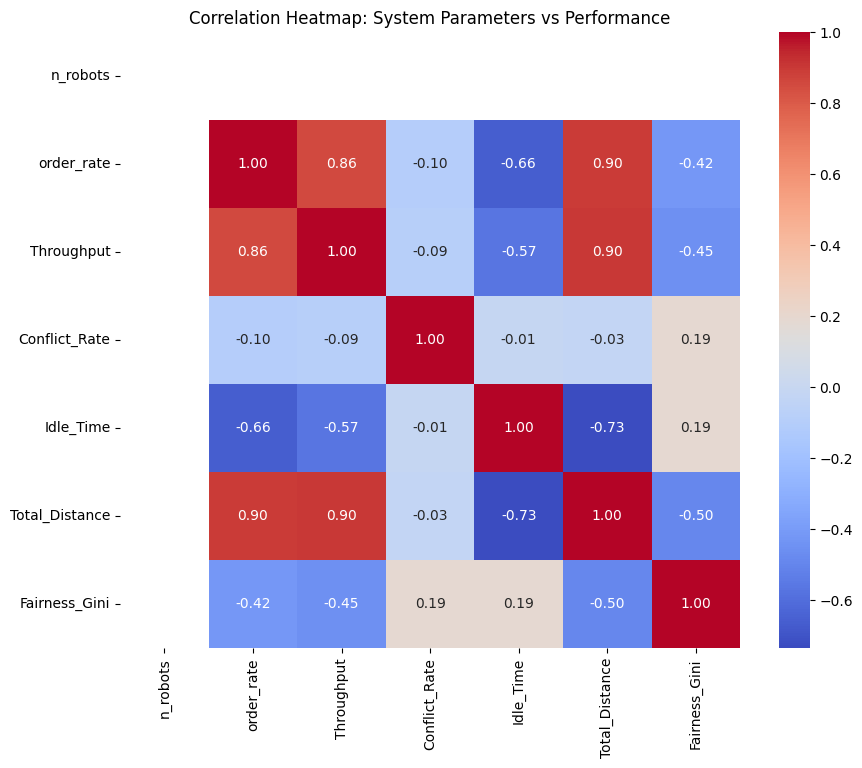

In [4]:
plt.figure(figsize=(10, 8))
corr_cols = ['n_robots', 'order_rate', 'Throughput', 'Conflict_Rate', 'Idle_Time', 'Total_Distance', 'Fairness_Gini']
correlation_matrix = final_runs[corr_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: System Parameters vs Performance')
plt.show()

**Interpretation:** the system's efficiency is primarily driven by the Order Rate, which simultaneously maximizes output and minimizes idle time. Most importantly, the negative link between the Gini index and throughput validates our coordination logic: by ensuring no single robot is overloaded (improving fairness), the system maintains higher sustained performance. This statistical evidence strongly supports the use of **Auction** or **CNP** mechanisms, as they are designed to optimize the fairness-efficiency balance that the heatmap identifies as crucial.

#### 3. Efficiency Metric: Distance Traveled per Order

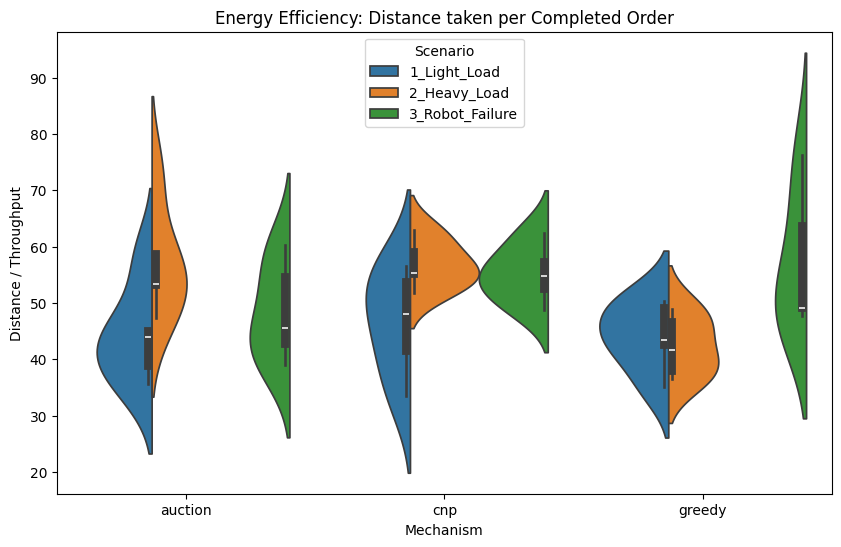

In [5]:
final_runs['Energy_Efficiency'] = final_runs['Total_Distance'] / final_runs['Throughput']

plt.figure(figsize=(10, 6))
sns.violinplot(data=final_runs, x='Mechanism', y='Energy_Efficiency', hue='Scenario', split=True)
plt.title('Energy Efficiency: Distance taken per Completed Order')
plt.ylabel('Distance / Throughput')
plt.show()

**Interpretation:** we can conclude that there is a fundamental trade-off between raw speed and predictable stability:

- Greedy is best for raw, reactive speed in simple scenarios but is highly unstable and energy-inefficient during system failures.

- CNP is the superior choice for social balance, ensuring that workload is distributed most evenly across the fleet.

- Auction provides a stable, energy-conscious solution. While it has higher idle time due to negotiation overhead, it successfully incorporates long-term system health into its decision-making.

***Scenario 3 – The Rescue System Test***

C:\Users\ff\AppData\Local\Temp\ipykernel_4344\3052354985.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(data=fail_df, x='Step', y='Throughput', hue='Mechanism', ci=95)


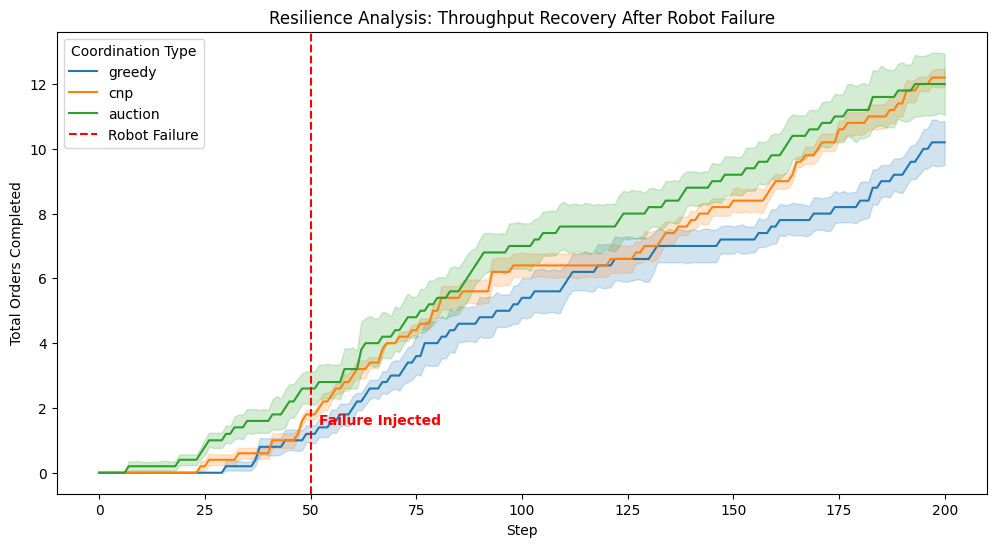

In [6]:
# Filter for the failure scenario
fail_df = df[df['Scenario'] == '3_Robot_Failure']

plt.figure(figsize=(12, 6))
sns.lineplot(data=fail_df, x='Step', y='Throughput', hue='Mechanism', ci=95)

# Visual markers for the report
plt.axvline(x=50, color='red', linestyle='--', label='Robot Failure')
plt.text(52, fail_df['Throughput'].max()*0.1, "Failure Injected", color='red', fontweight='bold')

plt.title("Resilience Analysis: Throughput Recovery After Robot Failure")
plt.xlabel("Step")
plt.ylabel("Total Orders Completed")
plt.legend(title="Coordination Type")
plt.show()

**Interpretation:** The figure shows that **Auction** and **CNP** demonstrate superior resilience, recovering more effectively from the step 50 failure to achieve higher total order completions. While all mechanisms suffer a performance dip, the Greedy approach exhibits the slowest recovery and lowest final throughput. Ultimately, the centralized mechanisms' ability to intelligently re-allocate orders ensures a more robust system recovery compared to reactive, independent robot behavior.

***Efficiency & Workload Fairness (Gini)***

C:\Users\ff\AppData\Local\Temp\ipykernel_4344\1033188455.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_stats, x='Mechanism', y='Fairness_Gini', ax=ax1, palette='Set2')


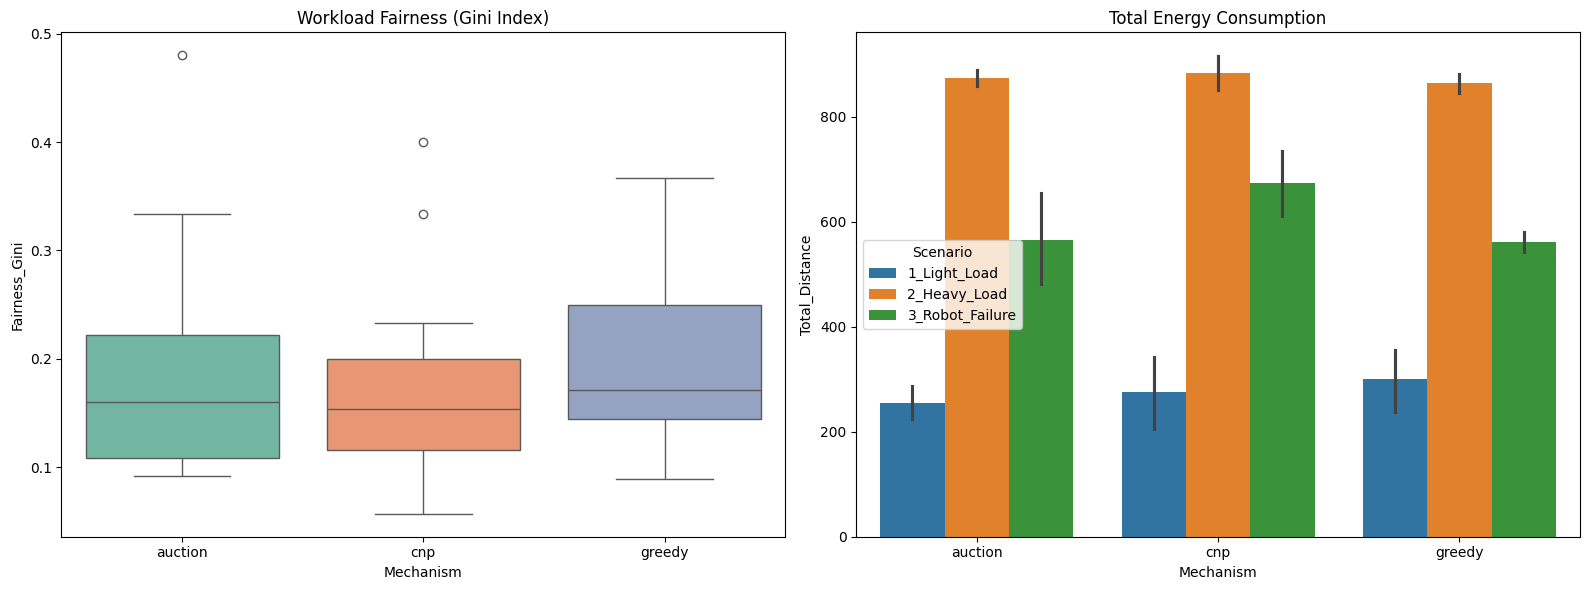

In [7]:
# Get the final state of each run to compare totals
final_stats = df.groupby(['Mechanism', 'Scenario', 'iteration']).last().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Workload Fairness (Gini: Lower is better)
sns.boxplot(data=final_stats, x='Mechanism', y='Fairness_Gini', ax=ax1, palette='Set2')
ax1.set_title("Workload Fairness (Gini Index)")

# 2. Total Distance Traveled (Energy Cost)
sns.barplot(data=final_stats, x='Mechanism', y='Total_Distance', hue='Scenario', ax=ax2)
ax2.set_title("Total Energy Consumption")

plt.tight_layout()
plt.show()

**Interpretation**: The analysis concludes that there is a fundamental trade-off between raw speed and predictable stability:

- Greedy is effective for raw reactive speed in low-complexity scenarios but is highly unstable and energy-inefficient during system failures.

- CNP is the optimal choice for social balance and equitable workload distribution across the fleet.

- Auction provides the most robust and sustainable solution for long-term operations, effectively balancing energy preservation with a resilient recovery from unexpected failures.

For a high-scale, resilient robotic warehouse operation, Auction-based coordination is the recommended choice as it successfully mitigates the high-variance risks and energy costs associated with independent, reactive behavior.